# Welly AI Project Progress Notebook

โครงงานนี้มุ่งพัฒนาระบบช่วยวิเคราะห์โภชนาการอาหารและให้คำแนะนำเบื้องต้นผ่าน chatbot
โดยใช้ข้อมูลอาหารเชิงโครงสร้างร่วมกับความรู้จากเอกสารมาตรฐานด้านโภชนาการ

## 1. Review Scope Project

### Problem Statement
โครงงานนี้มีเป้าหมายเพื่อวิเคราะห์ข้อมูลโภชนาการของอาหาร และประเมินระดับความเสี่ยงเบื้องต้นของอาหารแต่ละรายการ
โดยอาศัยข้อมูลโภชนาการ เช่น calories, fat, saturated fat, sugar, cholesterol และ sodium

### Initial Scope
เดิมโครงงานมีแนวคิดกว้าง ครอบคลุมทั้ง nutrition analysis, recommendation และ chatbot

### Comments Received
- ควรลด scope ให้ชัดขึ้น
- ควรเลือก structured dataset หลักให้ชัดเจน
- ควรมี EDA, Data Preparation และ Modelling ที่เห็นขั้นตอนชัด
- หากใช้ PDF ควรแปลงให้เป็น structured knowledge ก่อน

### Scope Adjustment
หลังจากได้รับ comment ได้ปรับขอบเขตโครงงานดังนี้
1. ใช้ food/nutrition dataset เป็น structured dataset หลัก
2. ใช้ข้อมูลจาก PDF เป็น external knowledge/reference
3. แปลงข้อมูลจาก PDF ให้อยู่ในรูป structured tables
4. ใช้เกณฑ์จาก PDF เพื่อช่วยสร้าง logic/rules สำหรับประเมินอาหาร
5. ทดลองสร้าง baseline model สำหรับจัดระดับความเสี่ยงของอาหาร

## 2. Data Sources

### Structured Dataset
- FOOD-DATA-GROUP1.csv ถึง FOOD-DATA-GROUP5.csv
- Food Nutri.csv
- Food Nutri 2.csv
- calories.csv

### External Knowledge
- media.pdf
- DGA.pdf

### Objective of This Notebook
Notebook นี้ใช้สำหรับ
1. รวมและสำรวจข้อมูลอาหาร
2. ตรวจสอบคุณภาพข้อมูล
3. เตรียมข้อมูลสำหรับการสร้างโมเดล
4. ทดลอง baseline classification model

In [110]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Load Dataset

ในส่วนนี้เลือกใช้ FOOD-DATA-GROUP1 ถึง FOOD-DATA-GROUP5 เป็น dataset หลัก
และรวมข้อมูลทั้งหมดเข้าด้วยกันเพื่อใช้ในการวิเคราะห์

In [111]:
group_files = [
    '../data/FOOD-DATA-GROUP1.csv',
    '../data/FOOD-DATA-GROUP2.csv',
    '../data/FOOD-DATA-GROUP3.csv',
    '../data/FOOD-DATA-GROUP4.csv',
    '../data/FOOD-DATA-GROUP5.csv',
]

for f in group_files:
    print(f, '->', os.path.exists(f))

../data/FOOD-DATA-GROUP1.csv -> True
../data/FOOD-DATA-GROUP2.csv -> True
../data/FOOD-DATA-GROUP3.csv -> True
../data/FOOD-DATA-GROUP4.csv -> True
../data/FOOD-DATA-GROUP5.csv -> True


In [112]:
df_list = [pd.read_csv(f) for f in group_files]
df = pd.concat(df_list, ignore_index=True)

print('Combined shape:', df.shape)
df.head()

Combined shape: (2395, 37)


,Unnamed: 0.1,Unnamed: 0,food,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,Protein,Dietary Fiber,Cholesterol,Sodium,Water,Vitamin A,Vitamin B1,Vitamin B11,Vitamin B12,Vitamin B2,Vitamin B3,Vitamin B5,Vitamin B6,Vitamin C,Vitamin D,Vitamin E,Vitamin K,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc,Nutrition Density
0,0,0,cream cheese,51,5.0,2.9,1.3,0.200,0.8,0.500,0.9,0.0,14.6,0.016,7.6,0.200,0.033,0.064,0.092,0.097,0.084,0.052,0.096,0.004,0.000,0.000,0.100,0.008,14.100,0.082,0.027,1.300,0.091,15.5,19.100,0.039,7.070
1,1,1,neufchatel cheese,215,19.4,10.9,4.9,0.800,3.1,2.700,7.8,0.0,62.9,0.300,53.6,0.200,0.099,0.079,0.090,0.100,0.200,0.500,0.078,0.000,0.000,0.300,0.045,99.500,0.034,0.100,8.500,0.088,117.300,129.2,0.054,0.700,130.100
2,2,2,requeijao cremoso light catupiry,49,3.6,2.3,0.9,0.000,0.9,3.400,0.8,0.1,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,5.400
3,3,3,ricotta cheese,30,2.0,1.3,0.5,0.002,1.5,0.091,1.5,0.0,9.8,0.017,14.7,0.075,0.019,0.079,0.091,0.027,0.041,0.016,0.007,0.006,0.000,0.001,0.011,0.097,41.200,0.097,0.096,4.000,0.024,30.8,43.800,0.035,5.196
4,4,4,cream cheese low fat,30,2.3,1.4,0.6,0.042,1.2,0.900,1.2,0.0,8.1,0.046,10.0,0.016,0.080,0.062,0.049,0.026,0.080,0.100,0.003,0.000,0.036,0.009,0.019,22.200,0.072,0.008,1.200,0.098,22.800,37.1,0.034,0.053,27.007


In [113]:
print(df.columns.tolist())

['Unnamed: 0.1', 'Unnamed: 0', 'food', 'Caloric Value', 'Fat', 'Saturated Fats', 'Monounsaturated Fats', 'Polyunsaturated Fats', 'Carbohydrates', 'Sugars', 'Protein', 'Dietary Fiber', 'Cholesterol', 'Sodium', 'Water', 'Vitamin A', 'Vitamin B1', 'Vitamin B11', 'Vitamin B12', 'Vitamin B2', 'Vitamin B3', 'Vitamin B5', 'Vitamin B6', 'Vitamin C', 'Vitamin D', 'Vitamin E', 'Vitamin K', 'Calcium', 'Copper', 'Iron', 'Magnesium', 'Manganese', 'Phosphorus', 'Potassium', 'Selenium', 'Zinc', 'Nutrition Density']


## 4. Exploratory Data Analysis (EDA)

เริ่มจากการสำรวจโครงสร้างข้อมูล ได้แก่ จำนวนแถว จำนวนคอลัมน์ ชนิดข้อมูล
และการตรวจสอบ missing values ก่อนวิเคราะห์เชิงลึก

In [114]:
print('Shape:', df.shape)

Shape: (2395, 37)


In [115]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2395 entries, 0 to 2394
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0.1          2395 non-null   int64  
 1   Unnamed: 0            2395 non-null   int64  
 2   food                  2395 non-null   str    
 3   Caloric Value         2395 non-null   int64  
 4   Fat                   2395 non-null   float64
 5   Saturated Fats        2395 non-null   float64
 6   Monounsaturated Fats  2395 non-null   float64
 7   Polyunsaturated Fats  2395 non-null   float64
 8   Carbohydrates         2395 non-null   float64
 9   Sugars                2395 non-null   float64
 10  Protein               2395 non-null   float64
 11  Dietary Fiber         2395 non-null   float64
 12  Cholesterol           2395 non-null   float64
 13  Sodium                2395 non-null   float64
 14  Water                 2395 non-null   float64
 15  Vitamin A             2395 non-n

In [116]:
df.isnull().sum().sort_values(ascending=False)

Unnamed: 0.1            0
Vitamin B2              0
Vitamin B5              0
Vitamin B6              0
Vitamin C               0
Vitamin D               0
Vitamin E               0
Vitamin K               0
Calcium                 0
Copper                  0
Iron                    0
Magnesium               0
Manganese               0
Phosphorus              0
Potassium               0
Selenium                0
Zinc                    0
Vitamin B3              0
Vitamin B12             0
Unnamed: 0              0
Vitamin B11             0
food                    0
Caloric Value           0
Fat                     0
Saturated Fats          0
Monounsaturated Fats    0
Polyunsaturated Fats    0
Carbohydrates           0
Sugars                  0
Protein                 0
Dietary Fiber           0
Cholesterol             0
Sodium                  0
Water                   0
Vitamin A               0
Vitamin B1              0
Nutrition Density       0
dtype: int64

In [117]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0.1,2395.0,NaN,NaN,NaN,272.258038,182.889214,0.0,119.0,241.0,414.5,721.0
Unnamed: 0,2395.0,NaN,NaN,NaN,272.258038,182.889214,0.0,119.0,241.0,414.5,721.0
food,2395,2395,cream cheese,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Caloric Value,2395.0,NaN,NaN,NaN,223.76952,384.728244,0.0,44.5,117.0,258.0,6077.0
Fat,2395.0,NaN,NaN,NaN,10.176276,29.008915,0.0,0.3,2.1,9.4,550.7
Saturated Fats,2395.0,NaN,NaN,NaN,3.924917,19.502262,0.0,0.064,0.5,2.7,672.0
Monounsaturated Fats,2395.0,NaN,NaN,NaN,4.133622,12.939587,0.0,0.058,0.5,3.4,291.1
Polyunsaturated Fats,2395.0,NaN,NaN,NaN,2.152844,7.145738,0.0,0.071,0.4,1.7,188.0
Carbohydrates,2395.0,NaN,NaN,NaN,18.589021,29.406134,0.0,0.5,6.8,25.05,390.2
Sugars,2395.0,NaN,NaN,NaN,4.457459,13.339929,0.0,0.0,0.086,3.2,291.5


### EDA Observation
จากการสำรวจเบื้องต้น พบว่าข้อมูลมีหลายคอลัมน์ด้านโภชนาการ และบางคอลัมน์อาจมี missing values
ดังนั้นจำเป็นต้องเลือกเฉพาะตัวแปรที่สำคัญและแปลงข้อมูลให้อยู่ในรูป numeric ก่อนเข้าสู่ขั้น Data Preparation

In [118]:
df.columns = [c.strip() for c in df.columns]
df.columns.tolist()

['Unnamed: 0.1',
 'Unnamed: 0',
 'food',
 'Caloric Value',
 'Fat',
 'Saturated Fats',
 'Monounsaturated Fats',
 'Polyunsaturated Fats',
 'Carbohydrates',
 'Sugars',
 'Protein',
 'Dietary Fiber',
 'Cholesterol',
 'Sodium',
 'Water',
 'Vitamin A',
 'Vitamin B1',
 'Vitamin B11',
 'Vitamin B12',
 'Vitamin B2',
 'Vitamin B3',
 'Vitamin B5',
 'Vitamin B6',
 'Vitamin C',
 'Vitamin D',
 'Vitamin E',
 'Vitamin K',
 'Calcium',
 'Copper',
 'Iron',
 'Magnesium',
 'Manganese',
 'Phosphorus',
 'Potassium',
 'Selenium',
 'Zinc',
 'Nutrition Density']

In [119]:
column_map_candidates = {
    'food_name': ['Food', 'food', 'Food Name', 'food_name', 'item', 'Item', 'Dish'],
    'calories': ['Caloric Value', 'Calories', 'calories', 'Energy', 'energy', 'kcal'],
    'fat': ['Fat', 'Total Fat', 'fat'],
    'sat_fat': ['Saturated Fats', 'Saturated Fat', 'sat_fat'],
    'carbs': ['Carbohydrates', 'Total Carbohydrate', 'carbs', 'Carbohydrate'],
    'sugar': ['Sugars', 'Sugar', 'sugar'],
    'protein': ['Protein', 'protein'],
    'fiber': ['Dietary Fiber', 'Fiber', 'fiber'],
    'cholesterol': ['Cholesterol', 'cholesterol'],
    'sodium': ['Sodium', 'sodium']
}

resolved_columns = {}
for std_name, options in column_map_candidates.items():
    found = None
    for opt in options:
        if opt in df.columns:
            found = opt
            break
    resolved_columns[std_name] = found

resolved_columns

{'food_name': 'food',
 'calories': 'Caloric Value',
 'fat': 'Fat',
 'sat_fat': 'Saturated Fats',
 'carbs': 'Carbohydrates',
 'sugar': 'Sugars',
 'protein': 'Protein',
 'fiber': 'Dietary Fiber',
 'cholesterol': 'Cholesterol',
 'sodium': 'Sodium'}

In [120]:
selected_cols = [v for v in resolved_columns.values() if v is not None]
df_eda = df[selected_cols].copy()

rename_dict = {v: k for k, v in resolved_columns.items() if v is not None}
df_eda = df_eda.rename(columns=rename_dict)

df_eda.head()

,food_name,calories,fat,sat_fat,carbs,sugar,protein,fiber,cholesterol,sodium
0,cream cheese,51,5.0,2.9,0.8,0.500,0.9,0.0,14.6,0.016
1,neufchatel cheese,215,19.4,10.9,3.1,2.700,7.8,0.0,62.9,0.300
2,requeijao cremoso light catupiry,49,3.6,2.3,0.9,3.400,0.8,0.1,0.0,0.000
3,ricotta cheese,30,2.0,1.3,1.5,0.091,1.5,0.0,9.8,0.017
4,cream cheese low fat,30,2.3,1.4,1.2,0.900,1.2,0.0,8.1,0.046


In [121]:
nutrition_cols = ['calories', 'fat', 'sat_fat', 'carbs', 'sugar', 'protein', 'fiber', 'cholesterol', 'sodium']

for col in nutrition_cols:
    if col not in df_eda.columns:
        df_eda[col] = np.nan
    df_eda[col] = pd.to_numeric(df_eda[col], errors='coerce')

df_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 2395 entries, 0 to 2394
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   food_name    2395 non-null   str    
 1   calories     2395 non-null   int64  
 2   fat          2395 non-null   float64
 3   sat_fat      2395 non-null   float64
 4   carbs        2395 non-null   float64
 5   sugar        2395 non-null   float64
 6   protein      2395 non-null   float64
 7   fiber        2395 non-null   float64
 8   cholesterol  2395 non-null   float64
 9   sodium       2395 non-null   float64
dtypes: float64(8), int64(1), str(1)
memory usage: 187.2 KB


In [122]:
df_eda[nutrition_cols].isnull().sum()

calories       0
fat            0
sat_fat        0
carbs          0
sugar          0
protein        0
fiber          0
cholesterol    0
sodium         0
dtype: int64

In [123]:
df_eda[nutrition_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
calories,2395.0,223.769520,384.728244,0.0,44.500,117.000,258.00,6077.0
fat,2395.0,10.176276,29.008915,0.0,0.300,2.100,9.40,550.7
sat_fat,2395.0,3.924917,19.502262,0.0,0.064,0.500,2.70,672.0
carbs,2395.0,18.589021,29.406134,0.0,0.500,6.800,25.05,390.2
sugar,2395.0,4.457459,13.339929,0.0,0.000,0.086,3.20,291.5
protein,2395.0,13.400777,32.294246,0.0,0.800,3.500,13.30,560.3
fiber,2395.0,2.235790,5.404483,0.0,0.000,0.200,2.20,76.5
cholesterol,2395.0,62.171937,385.352876,0.0,0.000,0.000,26.45,10509.0
sodium,2395.0,0.293888,1.116117,0.0,0.036,0.086,0.30,49.4


### Distribution of Nutrition Features

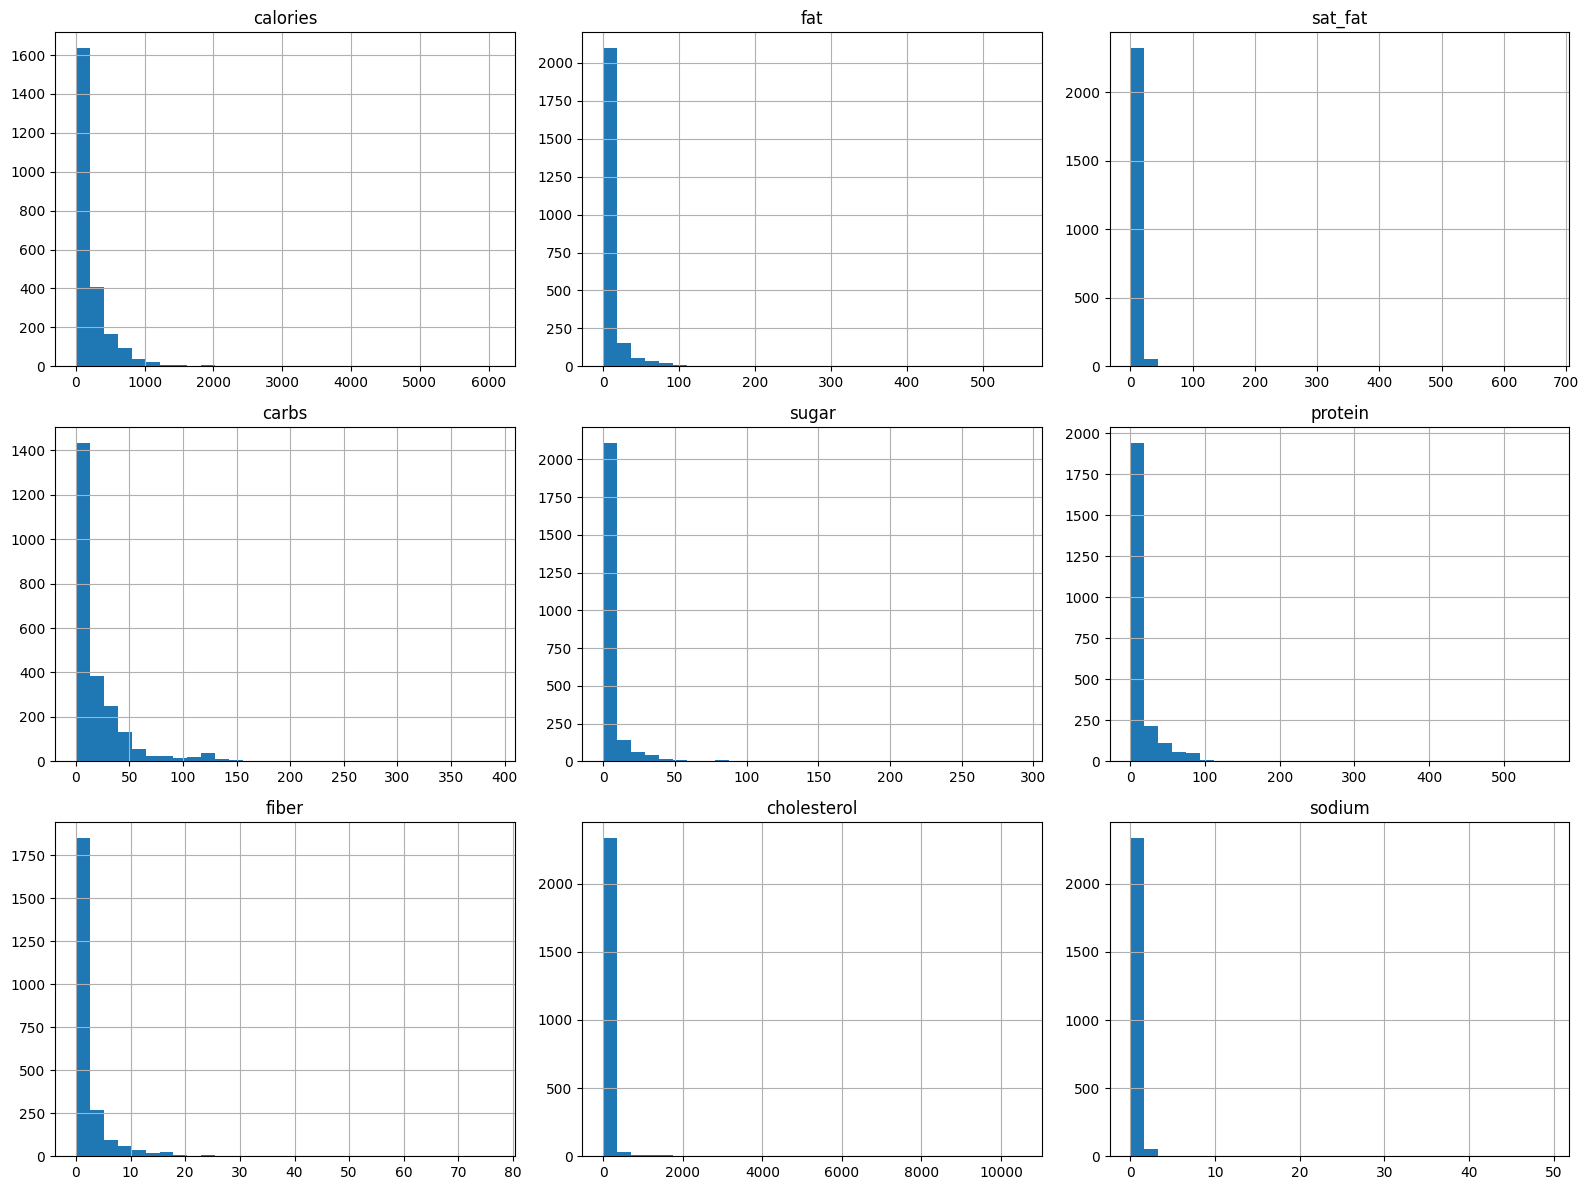

In [124]:
df_eda[nutrition_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

### Correlation Matrix

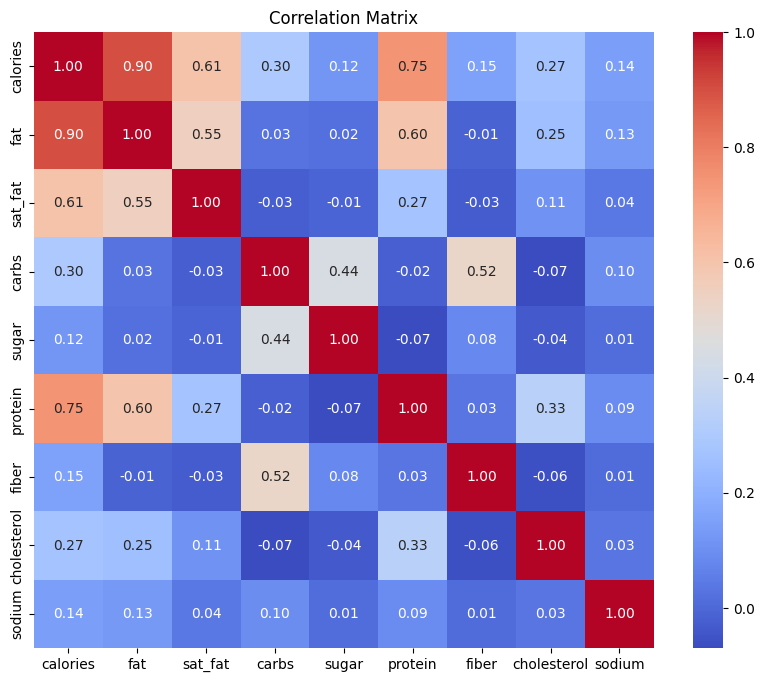

In [125]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_eda[nutrition_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### Outlier Check

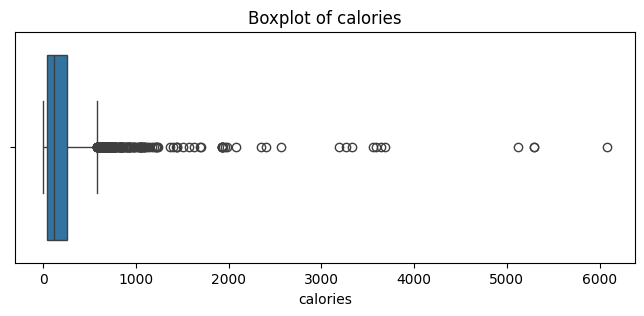

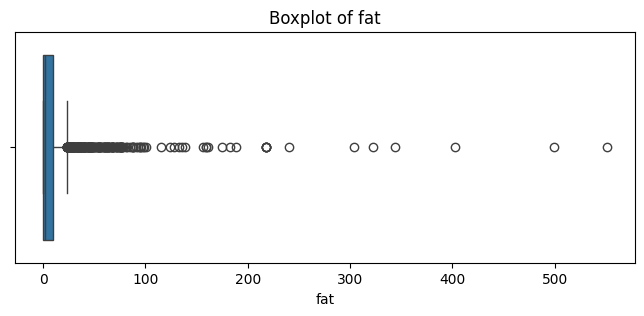

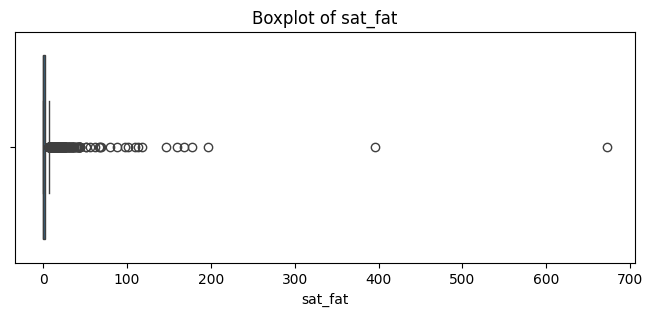

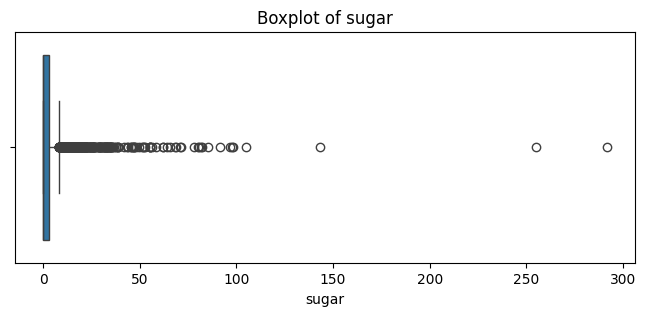

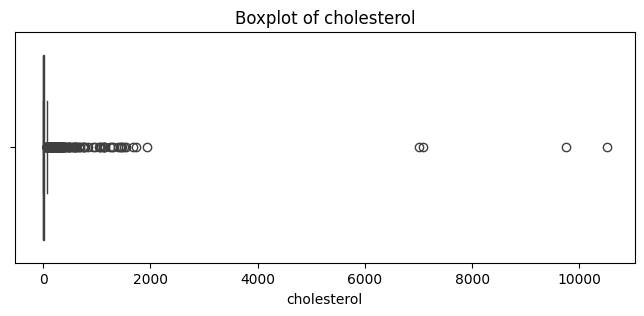

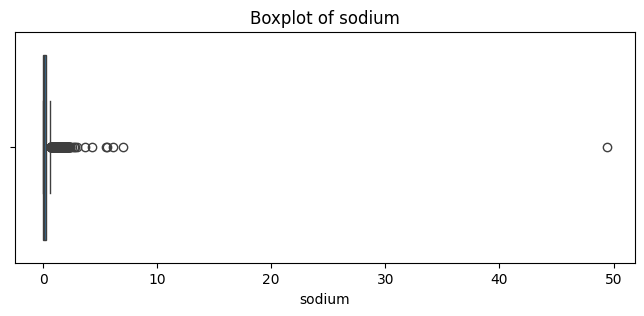

In [126]:
for col in ['calories', 'fat', 'sat_fat', 'sugar', 'cholesterol', 'sodium']:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df_eda[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [127]:
df_eda.sort_values('sodium', ascending=False).head(10)

,food_name,calories,fat,sat_fat,carbs,sugar,protein,fiber,cholesterol,sodium
1943,adobo fresco,780,60.2,8.4,53.600,5.8,5.8,3.7,0.0,49.4
1047,salt,0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,7.0
389,salt mackerel,415,34.1,9.7,0.000,0.0,25.2,0.0,129.2,6.1
370,jellyfish dried,21,0.8,0.2,0.000,0.0,3.2,0.0,2.9,5.6
1219,corned beef raw,898,67.6,21.5,0.600,0.0,66.6,0.0,244.9,5.5
1393,pork feet pickled,635,45.5,13.4,0.029,0.0,52.8,0.0,376.5,4.3
1382,pork blade roll roasted,1079,88.3,31.5,1.400,0.0,65.0,0.0,251.9,3.7
854,white rice pasta raw,600,4.0,0.7,122.800,0.0,15.3,0.0,3.3,3.0
707,banana cream pie,3190,161.3,44.6,390.200,143.0,52.2,8.3,604.9,2.8
848,rice pilaf raw,732,2.8,0.0,155.700,3.1,21.3,2.4,0.0,2.7


In [128]:
df_eda.sort_values('cholesterol', ascending=False).head(10)

,food_name,calories,fat,sat_fat,carbs,sugar,protein,fiber,cholesterol,sodium
1294,veal brain cooked,461,32.6,7.4,0.0,0.0,38.9,0.0,10509.0,0.5
1320,pork brain cooked,527,36.3,8.2,0.0,0.0,46.4,0.0,9748.6,0.3
1323,lamb brain cooked,503,35.3,9.0,0.0,0.0,43.5,0.0,7089.2,0.5
1299,beef brain cooked,688,55.6,13.1,0.0,0.0,44.1,0.0,7002.5,0.6
1376,pork arm picnic cooked,5292,322.7,109.3,0.0,0.0,560.3,0.0,1936.7,2.2
1374,pork arm picnic raw,5298,343.4,113.6,0.0,0.0,513.6,0.0,1729.4,2.3
1314,lamb liver cooked,739,29.6,11.5,8.5,0.0,102.7,0.0,1683.4,0.2
1313,veal spleen cooked,445,10.0,3.3,0.0,0.0,83.1,0.0,1542.2,0.2
1358,pork splean cooked,446,9.6,3.2,0.0,0.0,84.3,0.0,1507.0,0.3
1406,turkey breast raw,3554,158.9,43.2,0.0,0.0,495.6,0.0,1471.6,1.3


## EDA Summary

จากการวิเคราะห์เบื้องต้น พบว่า
- ตัวแปรโภชนาการหลายตัวมีการกระจายแบบเบ้ขวา
- มี outlier ชัดเจนใน sodium, cholesterol, sugar และ saturated fat
- sodium, saturated fat, sugar และ cholesterol เป็นตัวแปรสำคัญที่เหมาะสำหรับใช้ประเมินความเสี่ยงของอาหาร
- ข้อมูลบางส่วนยังมี missing values และต้องจัดการในขั้น Data Preparation

## 5. Load Structured Knowledge from PDF

ในส่วนนี้ใช้ความรู้ที่แปลงจาก PDF ให้อยู่ในรูป structured tables
เพื่อใช้เป็นเกณฑ์อ้างอิงในการประเมินอาหาร

In [129]:
standard_df = pd.read_csv('../data/knowledge/standard_df.csv')
claim_rules_df = pd.read_csv('../data/knowledge/claim_rules_df.csv')
dga_standard_df = pd.read_csv('../data/knowledge/dga_standard_df.csv')
dga_rules_df = pd.read_csv('../data/knowledge/dga_rules_df.csv')

standard_df

,source_doc,category,metric,recommended_value,unit,note
0,media.pdf,daily_reference,Energy,2000,kcal/day,Thai RDI reference base
1,media.pdf,daily_reference,Total Fat,65,g/day,Thai RDI reference
2,media.pdf,daily_reference,Saturated Fat,20,g/day,Thai RDI reference
3,media.pdf,daily_reference,Cholesterol,300,mg/day,Thai RDI reference
4,media.pdf,daily_reference,Total Carbohydrate,300,g/day,Thai RDI reference
5,media.pdf,daily_reference,Dietary Fiber,25,g/day,Thai RDI reference
6,media.pdf,daily_reference,Sodium,2000,mg/day,legacy value in source document


In [130]:
claim_rules_df

,source_doc,rule_name,condition_type,nutrient,value,unit
0,media.pdf,healthy_claim,max,Sodium,360,mg_per_serving_reference
1,media.pdf,healthy_claim,max,Cholesterol,60,mg_per_serving_reference
2,media.pdf,healthy_claim,min_percent_rdi,Protein/Fiber/Vitamin/Calcium/Iron,10,%Thai_RDI


ข้อมูลจาก PDF ถูกนำมาใช้เป็น external nutrition knowledge เช่น
- ค่าอ้างอิงรายวันของ sodium, cholesterol, saturated fat และ dietary fiber
- กฎเกี่ยวกับ healthy claim
- ข้อแนะนำจาก DGA เช่น sugar limit และ sodium limit

## 5.1 User Health Profile and BMI Assessment

ในส่วนนี้เพิ่มการประเมินข้อมูลพื้นฐานของผู้ใช้ เช่น น้ำหนัก ส่วนสูง เพศ และเส้นรอบเอว
เพื่อคำนวณ BMI และประเมินความเสี่ยงเบื้องต้น ซึ่งช่วยให้ระบบสามารถให้คำแนะนำแบบ personalized ได้มากขึ้น

In [131]:
# Example user profile
# สามารถเปลี่ยนค่าได้ตามผู้ใช้จริง
weight_kg = 70
height_cm = 170
gender = 'male'   # 'male' or 'female'
waist_cm = 88

height_m = height_cm / 100
bmi = weight_kg / (height_m ** 2)

def bmi_category_asian(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 23.0:
        return 'Normal'
    elif bmi < 25.0:
        return 'Overweight'
    elif bmi < 30.0:
        return 'Obese Level 1'
    else:
        return 'Obese Level 2'

def waist_risk(gender, waist_cm):
    gender = gender.lower()
    if gender == 'male':
        return 'High Risk' if waist_cm > 90 else 'Normal'
    elif gender == 'female':
        return 'High Risk' if waist_cm > 80 else 'Normal'
    return 'Unknown'

bmi_group = bmi_category_asian(bmi)
waist_status = waist_risk(gender, waist_cm)

protein_min = 1.2 * weight_kg
protein_max = 1.6 * weight_kg

user_profile_df = pd.DataFrame([
    {
        'weight_kg': weight_kg,
        'height_cm': height_cm,
        'gender': gender,
        'waist_cm': waist_cm,
        'bmi': round(bmi, 2),
        'bmi_category': bmi_group,
        'waist_risk': waist_status,
        'protein_min_g_day': round(protein_min, 2),
        'protein_max_g_day': round(protein_max, 2)
    }
])

user_profile_df

,weight_kg,height_cm,gender,waist_cm,bmi,bmi_category,waist_risk,protein_min_g_day,protein_max_g_day
0,70,170,male,88,24.22,Overweight,Normal,84.0,112.0


จากข้อมูลผู้ใช้ตัวอย่าง ระบบสามารถคำนวณ BMI และช่วงโปรตีนที่แนะนำต่อวันได้
โดยอ้างอิงสูตร BMI และคำแนะนำโปรตีนจากเอกสารมาตรฐาน ซึ่งช่วยให้การประเมินอาหารในขั้นต่อไปสอดคล้องกับข้อมูลของผู้ใช้มากขึ้น

In [132]:
print('BMI =', round(bmi, 2))
print('BMI Category =', bmi_group)
print('Waist Risk =', waist_status)
print('Recommended Protein Range =', round(protein_min, 2), '-', round(protein_max, 2), 'g/day')

BMI = 24.22
BMI Category = Overweight
Waist Risk = Normal
Recommended Protein Range = 84.0 - 112.0 g/day


### BMI / Body Measurement Standards

เพิ่ม structured knowledge สำหรับการประเมินสุขภาพของผู้ใช้จาก BMI และเส้นรอบเอว
เพื่อให้ระบบสามารถอ้างอิงเกณฑ์สุขภาพพื้นฐานของร่างกายได้ ไม่ใช่เฉพาะเกณฑ์โภชนาการของอาหาร

In [133]:
bmi_standard_df = pd.DataFrame([
    {
        'source_doc': 'document-20210831192536.pdf',
        'category': 'BMI',
        'metric': 'bmi_formula',
        'min_value': np.nan,
        'max_value': np.nan,
        'unit': 'kg/m^2',
        'target_group': 'general',
        'label': 'BMI = weight_kg / (height_m ** 2)',
        'note': 'ใช้สูตรน้ำหนัก(กก.) / ส่วนสูง(เมตร)^2'
    },
    {
        'source_doc': 'document-20210831192536.pdf',
        'category': 'BMI',
        'metric': 'bmi_category',
        'min_value': -np.inf,
        'max_value': 18.49,
        'unit': 'kg/m^2',
        'target_group': 'asian_adults',
        'label': 'Underweight',
        'note': 'น้ำหนักต่ำกว่าเกณฑ์'
    },
    {
        'source_doc': 'document-20210831192536.pdf',
        'category': 'BMI',
        'metric': 'bmi_category',
        'min_value': 18.5,
        'max_value': 22.99,
        'unit': 'kg/m^2',
        'target_group': 'asian_adults',
        'label': 'Normal',
        'note': 'น้ำหนักปกติ'
    },
    {
        'source_doc': 'document-20210831192536.pdf',
        'category': 'BMI',
        'metric': 'bmi_category',
        'min_value': 23.0,
        'max_value': 24.99,
        'unit': 'kg/m^2',
        'target_group': 'asian_adults',
        'label': 'Overweight',
        'note': 'น้ำหนักเกิน'
    },
    {
        'source_doc': 'document-20210831192536.pdf',
        'category': 'BMI',
        'metric': 'bmi_category',
        'min_value': 25.0,
        'max_value': 29.99,
        'unit': 'kg/m^2',
        'target_group': 'asian_adults',
        'label': 'Obese Level 1',
        'note': 'อ้วนระดับ 1'
    },
    {
        'source_doc': 'document-20210831192536.pdf',
        'category': 'BMI',
        'metric': 'bmi_category',
        'min_value': 30.0,
        'max_value': np.inf,
        'unit': 'kg/m^2',
        'target_group': 'asian_adults',
        'label': 'Obese Level 2',
        'note': 'อ้วนระดับ 2'
    },
    {
        'source_doc': 'document-20210831192536.pdf',
        'category': 'Waist Circumference',
        'metric': 'waist_risk_threshold',
        'min_value': np.nan,
        'max_value': 90,
        'unit': 'cm',
        'target_group': 'male',
        'label': 'Normal',
        'note': 'ผู้ชายควรมีเส้นรอบเอวไม่เกิน 90 ซม.'
    },
    {
        'source_doc': 'document-20210831192536.pdf',
        'category': 'Waist Circumference',
        'metric': 'waist_risk_threshold',
        'min_value': 90.01,
        'max_value': np.inf,
        'unit': 'cm',
        'target_group': 'male',
        'label': 'High Risk',
        'note': 'ผู้ชายเสี่ยงเมื่อเส้นรอบเอวเกิน 90 ซม.'
    },
    {
        'source_doc': 'document-20210831192536.pdf',
        'category': 'Waist Circumference',
        'metric': 'waist_risk_threshold',
        'min_value': np.nan,
        'max_value': 80,
        'unit': 'cm',
        'target_group': 'female',
        'label': 'Normal',
        'note': 'ผู้หญิงควรมีเส้นรอบเอวไม่เกิน 80 ซม.'
    },
    {
        'source_doc': 'document-20210831192536.pdf',
        'category': 'Waist Circumference',
        'metric': 'waist_risk_threshold',
        'min_value': 80.01,
        'max_value': np.inf,
        'unit': 'cm',
        'target_group': 'female',
        'label': 'High Risk',
        'note': 'ผู้หญิงเสี่ยงเมื่อเส้นรอบเอวเกิน 80 ซม.'
    }
])

bmi_standard_df

,source_doc,category,metric,min_value,max_value,unit,target_group,label,note
0,document-20210831192536.pdf,BMI,bmi_formula,NaN,NaN,kg/m^2,general,BMI = weight_kg / (height_m ** 2),ใช้สูตรน้ำหนัก(กก.) / ส่วนสูง(เมตร)^2
1,document-20210831192536.pdf,BMI,bmi_category,-inf,18.49,kg/m^2,asian_adults,Underweight,น้ำหนักต่ำกว่าเกณฑ์
2,document-20210831192536.pdf,BMI,bmi_category,18.50,22.99,kg/m^2,asian_adults,Normal,น้ำหนักปกติ
3,document-20210831192536.pdf,BMI,bmi_category,23.00,24.99,kg/m^2,asian_adults,Overweight,น้ำหนักเกิน
4,document-20210831192536.pdf,BMI,bmi_category,25.00,29.99,kg/m^2,asian_adults,Obese Level 1,อ้วนระดับ 1
5,document-20210831192536.pdf,BMI,bmi_category,30.00,inf,kg/m^2,asian_adults,Obese Level 2,อ้วนระดับ 2
6,document-20210831192536.pdf,Waist Circumference,waist_risk_threshold,NaN,90.00,cm,male,Normal,ผู้ชายควรมีเส้นรอบเอวไม่เกิน 90 ซม.
7,document-20210831192536.pdf,Waist Circumference,waist_risk_threshold,90.01,inf,cm,male,High Risk,ผู้ชายเสี่ยงเมื่อเส้นรอบเอวเกิน 90 ซม.
8,document-20210831192536.pdf,Waist Circumference,waist_risk_threshold,NaN,80.00,cm,female,Normal,ผู้หญิงควรมีเส้นรอบเอวไม่เกิน 80 ซม.
9,document-20210831192536.pdf,Waist Circumference,waist_risk_threshold,80.01,inf,cm,female,High Risk,ผู้หญิงเสี่ยงเมื่อเส้นรอบเอวเกิน 80 ซม.


In [134]:
bmi_rules_df = pd.DataFrame([
    {
        'source_doc': 'document-20210831192536.pdf',
        'rule_name': 'bmi_formula',
        'condition': 'BMI = weight_kg / (height_m ** 2)',
        'unit': 'kg/m^2',
        'note': 'สูตรคำนวณ BMI'
    },
    {
        'source_doc': 'document-20210831192536.pdf',
        'rule_name': 'waist_risk_male',
        'condition': 'waist_cm > 90',
        'unit': 'cm',
        'note': 'ผู้ชายเสี่ยงเมื่อเส้นรอบเอวมากกว่า 90 ซม.'
    },
    {
        'source_doc': 'document-20210831192536.pdf',
        'rule_name': 'waist_risk_female',
        'condition': 'waist_cm > 80',
        'unit': 'cm',
        'note': 'ผู้หญิงเสี่ยงเมื่อเส้นรอบเอวมากกว่า 80 ซม.'
    }
])

bmi_rules_df

,source_doc,rule_name,condition,unit,note
0,document-20210831192536.pdf,bmi_formula,BMI = weight_kg / (height_m ** 2),kg/m^2,สูตรคำนวณ BMI
1,document-20210831192536.pdf,waist_risk_male,waist_cm > 90,cm,ผู้ชายเสี่ยงเมื่อเส้นรอบเอวมากกว่า 90 ซม.
2,document-20210831192536.pdf,waist_risk_female,waist_cm > 80,cm,ผู้หญิงเสี่ยงเมื่อเส้นรอบเอวมากกว่า 80 ซม.


In [135]:
os.makedirs('../data/knowledge', exist_ok=True)

bmi_standard_df.to_csv('../data/knowledge/bmi_standard_df.csv', index=False)
bmi_rules_df.to_csv('../data/knowledge/bmi_rules_df.csv', index=False)

print('saved bmi_standard_df.csv and bmi_rules_df.csv')

saved bmi_standard_df.csv and bmi_rules_df.csv


ไฟล์มาตรฐาน BMI และกฎของเส้นรอบเอวถูกบันทึกไว้ใน `../data/knowledge/` แล้ว
เพื่อให้สามารถนำไปใช้ต่อกับการประเมินข้อมูลผู้ใช้และระบบ chatbot/RAG ได้

## 6. Data Preparation

ในขั้นตอนนี้จะทำ
- เลือกตัวแปรที่ใช้ในการสร้างโมเดล
- ลบข้อมูลซ้ำ
- จัดการ missing values
- สร้าง feature ใหม่จากเกณฑ์มาตรฐาน
- สร้าง target label สำหรับโมเดล

In [136]:
df_model = df_eda.copy()
before_rows = df_model.shape[0]

df_model = df_model.drop_duplicates()
after_rows = df_model.shape[0]

print('Rows before:', before_rows)
print('Rows after removing duplicates:', after_rows)

Rows before: 2395
Rows after removing duplicates: 2395


In [137]:
for col in nutrition_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

df_model.isnull().sum()

food_name      0
calories       0
fat            0
sat_fat        0
carbs          0
sugar          0
protein        0
fiber          0
cholesterol    0
sodium         0
dtype: int64

In [138]:
standard_df = pd.read_csv("../data/knowledge/standard_df.csv")
dga_standard_df = pd.read_csv("../data/knowledge/dga_standard_df.csv")

THAI_RDI_SODIUM = standard_df.loc[
    standard_df["metric"] == "Sodium", "recommended_value"
].iloc[0]

THAI_RDI_CHOLESTEROL = standard_df.loc[
    standard_df["metric"] == "Cholesterol", "recommended_value"
].iloc[0]

THAI_RDI_SAT_FAT = standard_df.loc[
    standard_df["metric"] == "Saturated Fat", "recommended_value"
].iloc[0]

THAI_RDI_FAT = standard_df.loc[
    standard_df["metric"] == "Total Fat", "recommended_value"
].iloc[0]

THAI_RDI_CARBS = standard_df.loc[
    standard_df["metric"] == "Total Carbohydrate", "recommended_value"
].iloc[0]

THAI_RDI_FIBER = standard_df.loc[
    standard_df["metric"] == "Dietary Fiber", "recommended_value"
].iloc[0]


DGA_ADDED_SUGAR_LIMIT_PER_MEAL = dga_standard_df.loc[
    dga_standard_df["metric"] == "added_sugar_limit_per_meal", "max_value"
].iloc[0]

In [139]:
df_model['sodium_pct_daily'] = (df_model['sodium'] / THAI_RDI_SODIUM) * 100
df_model['cholesterol_pct_daily'] = (df_model['cholesterol'] / THAI_RDI_CHOLESTEROL) * 100
df_model['sat_fat_pct_daily'] = (df_model['sat_fat'] / THAI_RDI_SAT_FAT) * 100
df_model['fat_pct_daily'] = (df_model['fat'] / THAI_RDI_FAT) * 100
df_model['carbs_pct_daily'] = (df_model['carbs'] / THAI_RDI_CARBS) * 100
df_model['fiber_pct_daily'] = (df_model['fiber'] / THAI_RDI_FIBER) * 100
df_model['sugar_pct_meal_limit'] = (df_model['sugar'] / DGA_ADDED_SUGAR_LIMIT_PER_MEAL) * 100

df_model.head()

,food_name,calories,fat,sat_fat,carbs,sugar,protein,fiber,cholesterol,sodium,sodium_pct_daily,cholesterol_pct_daily,sat_fat_pct_daily,fat_pct_daily,carbs_pct_daily,fiber_pct_daily,sugar_pct_meal_limit
0,cream cheese,51,5.0,2.9,0.8,0.500,0.9,0.0,14.6,0.016,0.00080,4.866667,14.5,7.692308,0.266667,0.0,5.00
1,neufchatel cheese,215,19.4,10.9,3.1,2.700,7.8,0.0,62.9,0.300,0.01500,20.966667,54.5,29.846154,1.033333,0.0,27.00
2,requeijao cremoso light catupiry,49,3.6,2.3,0.9,3.400,0.8,0.1,0.0,0.000,0.00000,0.000000,11.5,5.538462,0.300000,0.4,34.00
3,ricotta cheese,30,2.0,1.3,1.5,0.091,1.5,0.0,9.8,0.017,0.00085,3.266667,6.5,3.076923,0.500000,0.0,0.91
4,cream cheese low fat,30,2.3,1.4,1.2,0.900,1.2,0.0,8.1,0.046,0.00230,2.700000,7.0,3.538462,0.400000,0.0,9.00


Feature ใหม่เหล่านี้ช่วยให้สามารถตีความข้อมูลอาหารในเชิงมาตรฐานสุขภาพได้ง่ายขึ้น
เช่น sodium_pct_daily แสดงว่าอาหารหนึ่งรายการคิดเป็นกี่เปอร์เซ็นต์ของ sodium ต่อวันที่แนะนำ

In [140]:
def create_risk_label(row):
    score = 0

    if row['sodium'] >= THAI_RDI_SODIUM:
        score += 1
    if row['sat_fat'] >= THAI_RDI_SAT_FAT:
        score += 1
    if row['cholesterol'] >= THAI_RDI_CHOLESTEROL:
        score += 1
    if row['sugar'] >= DGA_ADDED_SUGAR_LIMIT_PER_MEAL:
        score += 1

    if score >= 3:
        return 'High'
    elif score >= 1:
        return 'Medium'
    return 'Low'

In [141]:
df_model['risk_level'] = df_model.apply(create_risk_label, axis=1)
df_model['risk_level'].value_counts()

risk_level
Low       1977
Medium     417
High         1
Name: count, dtype: int64

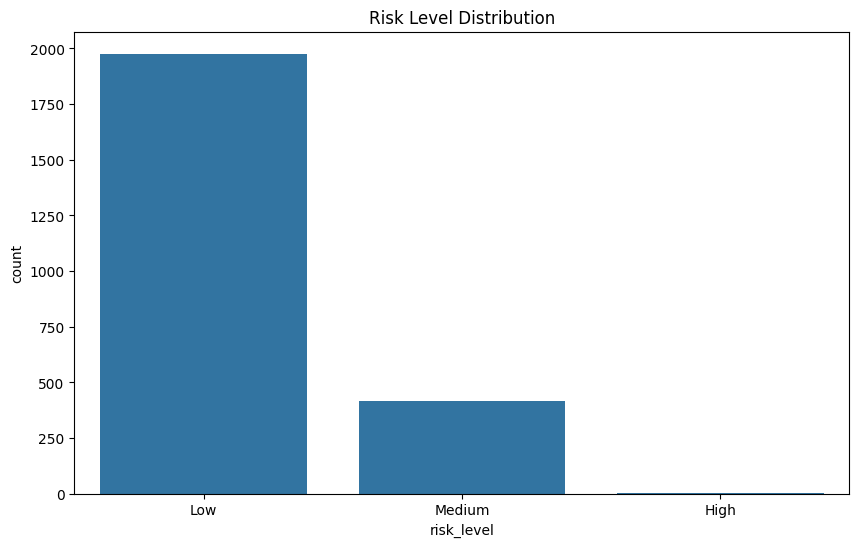

In [142]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df_model["risk_level"], order=["Low", "Medium", "High"])
plt.title("Risk Level Distribution")
plt.show()

In [143]:
label_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_model['risk_label'] = df_model['risk_level'].map(label_map)

df_model.head()

,food_name,calories,fat,sat_fat,carbs,sugar,protein,fiber,cholesterol,sodium,sodium_pct_daily,cholesterol_pct_daily,sat_fat_pct_daily,fat_pct_daily,carbs_pct_daily,fiber_pct_daily,sugar_pct_meal_limit,risk_level,risk_label
0,cream cheese,51,5.0,2.9,0.8,0.500,0.9,0.0,14.6,0.016,0.00080,4.866667,14.5,7.692308,0.266667,0.0,5.00,Low,0
1,neufchatel cheese,215,19.4,10.9,3.1,2.700,7.8,0.0,62.9,0.300,0.01500,20.966667,54.5,29.846154,1.033333,0.0,27.00,Low,0
2,requeijao cremoso light catupiry,49,3.6,2.3,0.9,3.400,0.8,0.1,0.0,0.000,0.00000,0.000000,11.5,5.538462,0.300000,0.4,34.00,Low,0
3,ricotta cheese,30,2.0,1.3,1.5,0.091,1.5,0.0,9.8,0.017,0.00085,3.266667,6.5,3.076923,0.500000,0.0,0.91,Low,0
4,cream cheese low fat,30,2.3,1.4,1.2,0.900,1.2,0.0,8.1,0.046,0.00230,2.700000,7.0,3.538462,0.400000,0.0,9.00,Low,0


ในขั้นนี้ได้สร้าง target variable คือ risk_level โดยอาศัยกฎจากเกณฑ์โภชนาการ
เพื่อใช้เป็น baseline target สำหรับการทดลองสร้าง classification model

In [144]:
feature_cols = [
    'calories',
    'fat',
    'sat_fat',
    'carbs',
    'sugar',
    'protein',
    'fiber',
    'cholesterol',
    'sodium',
    'sodium_pct_daily',
    'cholesterol_pct_daily',
    'sat_fat_pct_daily',
    'fat_pct_daily',
    'carbs_pct_daily',
    'fiber_pct_daily',
    'sugar_pct_meal_limit'
]

X = df_model[feature_cols]
y = df_model['risk_label']

X.shape, y.shape

((2395, 16), (2395,))

In [145]:
print(df_model["risk_label"].value_counts())

# เก็บเฉพาะ class ที่มีมากกว่า 1 ตัว
valid_classes = df_model["risk_label"].value_counts()
valid_classes = valid_classes[valid_classes > 1].index

df_model_filtered = df_model[df_model["risk_label"].isin(valid_classes)].copy()

X = df_model_filtered[feature_cols]
y = df_model_filtered["risk_label"]

print("\nFiltered class counts:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

risk_label
0    1977
1     417
2       1
Name: count, dtype: int64

Filtered class counts:
risk_label
0    1977
1     417
Name: count, dtype: int64
Train: (1915, 16) (1915,)
Test : (479, 16) (479,)


In [146]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train:', X_train.shape, y_train.shape)
print('Test:', X_test.shape, y_test.shape)

Train: (1915, 16) (1915,)
Test: (479, 16) (479,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000, class_weight="balanced")
dt = DecisionTreeClassifier(random_state=42, max_depth=5, class_weight="balanced")
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")

## 7. Modelling

ในขั้นตอนนี้ทดลอง baseline models 3 แบบ ได้แก่
- Logistic Regression
- Decision Tree
- Random Forest

In [100]:
lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

dt_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', DecisionTreeClassifier(random_state=42, max_depth=5))
])

rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [101]:
lr_pipeline.fit(X_train, y_train)
dt_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_pred_dt = dt_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

In [151]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
    ]
}).sort_values('Accuracy', ascending=False)

results

,Model,Accuracy
1,Decision Tree,1.000000
2,Random Forest,1.000000
0,Logistic Regression,0.987474


In [153]:
print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr))

print('=== Decision Tree ===')
print(classification_report(y_test, y_pred_dt))

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       396
           1       0.96      0.96      0.96        83

    accuracy                           0.99       479
   macro avg       0.98      0.98      0.98       479
weighted avg       0.99      0.99      0.99       479

=== Decision Tree ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       396
           1       1.00      1.00      1.00        83

    accuracy                           1.00       479
   macro avg       1.00      1.00      1.00       479
weighted avg       1.00      1.00      1.00       479

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       396
           1       1.00      1.00      1.00        83

    accuracy                           1.00       479
   macro avg       1.00      1.00      1.00       479
we

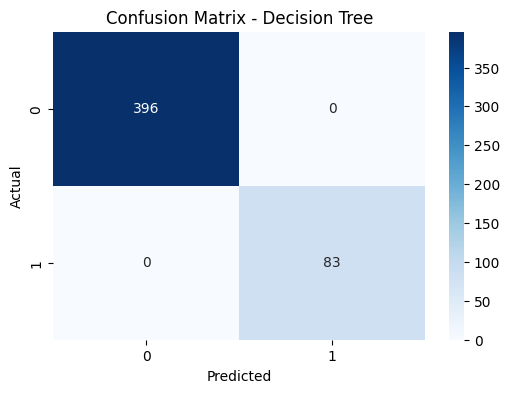

In [154]:
best_model_name = results.iloc[0]['Model']

if best_model_name == 'Logistic Regression':
    best_pred = y_pred_lr
elif best_model_name == 'Decision Tree':
    best_pred = y_pred_dt
else:
    best_pred = y_pred_rf

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [105]:
rf_model = rf_pipeline.named_steps['model']
importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

importances

,feature,importance
4,sugar,0.319188
15,sugar_pct_meal_limit,0.298540
7,cholesterol,0.088484
10,cholesterol_pct_daily,0.077354
11,sat_fat_pct_daily,0.065305
2,sat_fat,0.054373
13,carbs_pct_daily,0.019137
5,protein,0.017540
3,carbs,0.015320
12,fat_pct_daily,0.013099


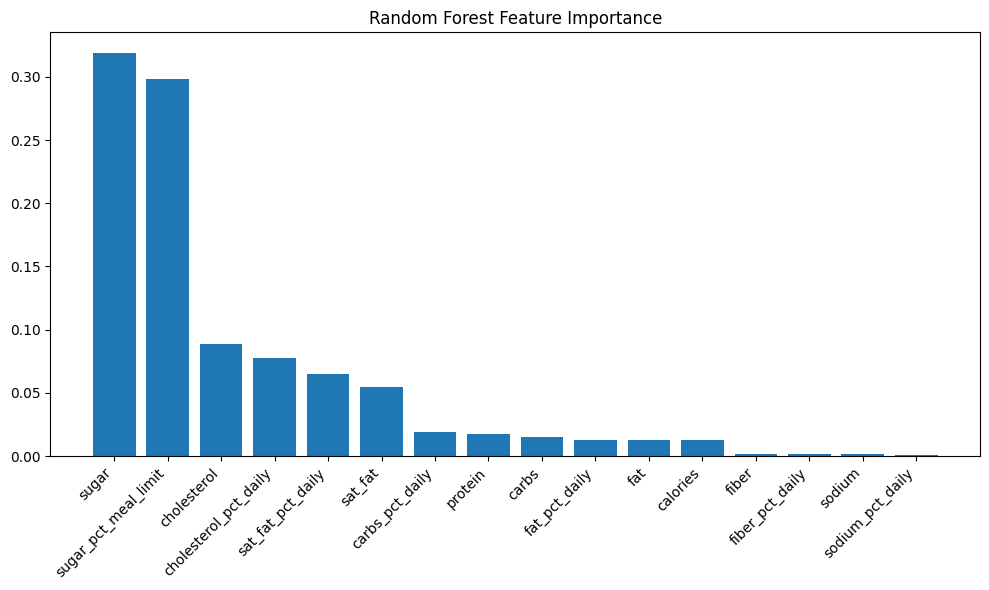

In [106]:
plt.figure(figsize=(10, 6))
plt.bar(importances['feature'], importances['importance'])
plt.xticks(rotation=45, ha='right')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

In [107]:
def evaluate_food_item(row):
    messages = []

    if row['sodium'] >= 360:
        messages.append('โซเดียมค่อนข้างสูง')
    if row['cholesterol'] >= 60:
        messages.append('โคเลสเตอรอลค่อนข้างสูง')
    if row['sugar'] >= 10:
        messages.append('น้ำตาลถึงหรือเกิน 10 กรัมต่อมื้อ')
    if row['sat_fat'] >= 6:
        messages.append('ไขมันอิ่มตัวค่อนข้างสูง')

    if not messages:
        messages.append('ยังไม่พบตัวชี้วัดที่เกินเกณฑ์เบื้องต้น')

    return ' | '.join(messages)

In [157]:
df_model['chatbot_summary'] = df_model.apply(evaluate_food_item, axis=1)

if 'food_name' in df_model.columns:
    df_model[['food_name', 'risk_level', 'chatbot_summary']].head(10)
else:
    df_model[['risk_level', 'chatbot_summary']].head(10)

In [159]:
os.makedirs('../outputs', exist_ok=True)

df_model.to_csv('../outputs/food_dataset_with_risk.csv', index=False)
results.to_csv('../outputs/model_results.csv', index=False)
importances.to_csv('../outputs/feature_importance.csv', index=False)

print('saved outputs successfully')

saved outputs successfully


## เล่นสนุก

## User Input and BMI-based Food Recommendation

ในส่วนนี้จะใช้ข้อมูลผู้ใช้เบื้องต้น ได้แก่ น้ำหนักและส่วนสูง
เพื่อคำนวณ BMI และใช้ร่วมกับ knowledge ที่มีอยู่
ในการแนะนำอาหารเบื้องต้น

In [165]:
import os
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

### 1. User Input
รับข้อมูลผู้ใช้เบื้องต้น ได้แก่ น้ำหนักและส่วนสูง

In [ ]:
weight_kg = 70
height_cm = 170

height_m = height_cm / 100
bmi = weight_kg / (height_m ** 2)

print("Weight (kg):", weight_kg)
print("Height (cm):", height_cm)
print("BMI:", round(bmi, 2))

### 2. Load Knowledge Files
โหลดค่ามาตรฐานจาก knowledge ที่เตรียมไว้

In [167]:
standard_path = "../data/knowledge/standard_df.csv"
dga_path = "../data/knowledge/dga_standard_df.csv"
bmi_standard_path = "../data/knowledge/bmi_standard_df.csv"

standard_df = pd.read_csv(standard_path) if os.path.exists(standard_path) else pd.DataFrame()
dga_standard_df = pd.read_csv(dga_path) if os.path.exists(dga_path) else pd.DataFrame()
bmi_standard_df = pd.read_csv(bmi_standard_path) if os.path.exists(bmi_standard_path) else pd.DataFrame()

print("standard_df:", standard_df.shape)
print("dga_standard_df:", dga_standard_df.shape)
print("bmi_standard_df:", bmi_standard_df.shape)

standard_df: (7, 6)
dga_standard_df: (8, 7)
bmi_standard_df: (10, 9)


### 3. Helper Functions
สร้างฟังก์ชันสำหรับดึงค่าจาก knowledge tables

In [168]:
def get_standard_value(df, metric_name, column_name="recommended_value", default=None):
    if df.empty:
        return default
    
    row = df[df["metric"].astype(str).str.lower() == metric_name.lower()]
    if not row.empty and column_name in row.columns:
        return float(row.iloc[0][column_name])
    
    return default

### 4. Load Nutrition Standards
ดึงค่ามาตรฐานด้านโภชนาการจาก knowledge

In [169]:
THAI_RDI_SODIUM = get_standard_value(standard_df, "Sodium", "recommended_value", 2000)
THAI_RDI_CHOLESTEROL = get_standard_value(standard_df, "Cholesterol", "recommended_value", 300)
THAI_RDI_SAT_FAT = get_standard_value(standard_df, "Saturated Fat", "recommended_value", 20)
THAI_RDI_FAT = get_standard_value(standard_df, "Total Fat", "recommended_value", 65)
THAI_RDI_CARBS = get_standard_value(standard_df, "Total Carbohydrate", "recommended_value", 300)
THAI_RDI_FIBER = get_standard_value(standard_df, "Dietary Fiber", "recommended_value", 25)

if not dga_standard_df.empty:
    row = dga_standard_df[
        dga_standard_df["metric"].astype(str).str.lower() == "added_sugar_limit_per_meal"
    ]
    if not row.empty:
        DGA_ADDED_SUGAR_LIMIT_PER_MEAL = float(row.iloc[0]["max_value"])
    else:
        DGA_ADDED_SUGAR_LIMIT_PER_MEAL = 10
else:
    DGA_ADDED_SUGAR_LIMIT_PER_MEAL = 10

print("THAI_RDI_SODIUM =", THAI_RDI_SODIUM)
print("THAI_RDI_CHOLESTEROL =", THAI_RDI_CHOLESTEROL)
print("THAI_RDI_SAT_FAT =", THAI_RDI_SAT_FAT)
print("THAI_RDI_FAT =", THAI_RDI_FAT)
print("THAI_RDI_CARBS =", THAI_RDI_CARBS)
print("THAI_RDI_FIBER =", THAI_RDI_FIBER)
print("DGA_ADDED_SUGAR_LIMIT_PER_MEAL =", DGA_ADDED_SUGAR_LIMIT_PER_MEAL)

THAI_RDI_SODIUM = 2000.0
THAI_RDI_CHOLESTEROL = 300.0
THAI_RDI_SAT_FAT = 20.0
THAI_RDI_FAT = 65.0
THAI_RDI_CARBS = 300.0
THAI_RDI_FIBER = 25.0
DGA_ADDED_SUGAR_LIMIT_PER_MEAL = 10.0


### 5. BMI Category
จัดกลุ่ม BMI ของผู้ใช้

In [170]:
def bmi_category_asian(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 23.0:
        return "Normal"
    elif bmi < 25.0:
        return "Overweight"
    elif bmi < 30.0:
        return "Obese Level 1"
    else:
        return "Obese Level 2"

bmi_group = bmi_category_asian(bmi)
print("BMI Category:", bmi_group)

BMI Category: Overweight


### 6. Check Food Dataset
ในขั้นนี้จะใช้ `df_model` ซึ่งควรมีอยู่แล้วจาก notebook การเตรียมข้อมูลและ modelling

In [171]:
required_cols = ["calories", "fat", "sat_fat", "carbs", "sugar", "protein", "fiber", "cholesterol", "sodium", "risk_level"]

missing_cols = [col for col in required_cols if col not in df_model.columns]
print("Missing columns:", missing_cols)

Missing columns: []


### 7. BMI-based Food Recommendation
ใช้ BMI ของผู้ใช้ร่วมกับข้อมูลโภชนาการของอาหาร
เพื่อคัดเลือกอาหารที่เหมาะสมเบื้องต้น

In [172]:
recommended_foods = df_model.copy()

if bmi_group == "Underweight":
    recommended_foods = recommended_foods[
        (recommended_foods["risk_level"] == "Low") &
        (recommended_foods["protein"] >= recommended_foods["protein"].median())
    ].sort_values(["calories", "protein"], ascending=[False, False])

elif bmi_group == "Normal":
    recommended_foods = recommended_foods[
        recommended_foods["risk_level"] == "Low"
    ].sort_values(["protein", "fiber"], ascending=[False, False])

else:  # Overweight / Obese
    recommended_foods = recommended_foods[
        (recommended_foods["risk_level"] == "Low") &
        (recommended_foods["sugar"] < DGA_ADDED_SUGAR_LIMIT_PER_MEAL) &
        (recommended_foods["fat"] < recommended_foods["fat"].median()) &
        (recommended_foods["sodium"] < THAI_RDI_SODIUM * 0.2)
    ].sort_values(["calories", "fat", "sugar"], ascending=[True, True, True])

print("BMI Group:", bmi_group)
print("Recommended foods shape:", recommended_foods.shape)

BMI Group: Overweight
Recommended foods shape: (1029, 20)


### 8. Show Top Recommendations
แสดงอาหารที่แนะนำเบื้องต้น

In [173]:
preview_cols = ["risk_level", "calories", "protein", "fat", "sugar", "cholesterol", "sodium"]

if "food_name" in recommended_foods.columns:
    preview_cols = ["food_name"] + preview_cols

recommended_foods[preview_cols].head(10)

,food_name,risk_level,calories,protein,fat,sugar,cholesterol,sodium
628,baking soda,Low,0,0.0,0.0,0.0,0.0,1.300
743,milk chocolate with rice cereal,Low,0,0.0,0.0,0.0,0.0,0.000
1047,salt,Low,0,0.0,0.0,0.0,0.0,7.000
1200,veal shoulder raw,Low,0,0.0,0.0,0.0,0.0,0.000
1493,coffee decaffeinated,Low,0,0.2,0.0,0.0,0.0,0.058
1505,powerade zero ion4 coca cola,Low,0,0.0,0.0,0.0,0.0,0.030
1549,water dannon,Low,0,0.0,0.0,0.0,0.0,0.000
1550,tap water,Low,0,0.0,0.0,0.0,0.0,0.018
1551,table water,Low,0,0.0,0.0,0.0,0.0,0.044
1553,water,Low,0,0.0,0.0,0.0,0.0,0.024


### 9. Generate Recommendation Summary
สร้างข้อความสรุปสำหรับอธิบายผลการแนะนำอาหาร

In [174]:
def recommendation_summary(bmi_group):
    if bmi_group == "Underweight":
        return "ผู้ใช้อยู่ในกลุ่มน้ำหนักต่ำกว่าเกณฑ์ จึงเน้นอาหารที่มีความเสี่ยงต่ำและมีโปรตีนหรือพลังงานค่อนข้างสูง"
    elif bmi_group == "Normal":
        return "ผู้ใช้อยู่ในกลุ่มน้ำหนักปกติ จึงเน้นอาหารที่มีความเสี่ยงต่ำและมีความสมดุลด้านโภชนาการ"
    else:
        return "ผู้ใช้อยู่ในกลุ่มน้ำหนักเกินหรืออ้วน จึงเน้นอาหารที่มีความเสี่ยงต่ำ น้ำตาลต่ำ ไขมันต่ำ และโซเดียมไม่สูง"

summary_text = recommendation_summary(bmi_group)
print(summary_text)

ผู้ใช้อยู่ในกลุ่มน้ำหนักเกินหรืออ้วน จึงเน้นอาหารที่มีความเสี่ยงต่ำ น้ำตาลต่ำ ไขมันต่ำ และโซเดียมไม่สูง


### 10. Save Recommendation Output
บันทึกผลลัพธ์เพื่อใช้งานต่อ

In [175]:
os.makedirs("../outputs", exist_ok=True)
recommended_foods.to_csv("../outputs/recommended_foods_by_bmi.csv", index=False)

print("saved: ../outputs/recommended_foods_by_bmi.csv")

saved: ../outputs/recommended_foods_by_bmi.csv


## Meal Plan Recommendation Modelling

ในส่วนนี้จะสร้างโมเดลเพื่อทำนาย Recommended_Meal_Plan
จากข้อมูลสุขภาพและพฤติกรรมของผู้ใช้

In [176]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [177]:
user_df = pd.read_csv("../data/Personalized_Diet_Recommendations.csv")
print(user_df.shape)
user_df.head()

(5000, 30)


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Chronic_Disease,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Level,Blood_Sugar_Level,Genetic_Risk_Factor,Allergies,Daily_Steps,Exercise_Frequency,Sleep_Hours,Alcohol_Consumption,Smoking_Habit,Dietary_Habits,Caloric_Intake,Protein_Intake,Carbohydrate_Intake,Fat_Intake,Preferred_Cuisine,Food_Aversions,Recommended_Calories,Recommended_Protein,Recommended_Carbs,Recommended_Fats,Recommended_Meal_Plan
0,P00001,56,Other,163,66,24.84,NaN,175,75,219,124,No,NaN,11452,5,7.6,No,Yes,Vegetarian,2593,105,179,143,Western,NaN,2150,108,139,145,High-Protein Diet
1,P00002,69,Female,171,114,38.99,NaN,155,72,208,72,No,NaN,12962,1,6.3,Yes,No,Vegetarian,1852,69,315,75,Mediterranean,NaN,1527,74,266,80,Balanced Diet
2,P00003,46,Female,172,119,40.22,NaN,137,101,171,145,No,Gluten Intolerance,7898,3,9.9,No,No,Vegetarian,2737,183,103,148,Western,Sweet,2359,180,145,143,High-Protein Diet
3,P00004,32,Female,197,118,30.41,NaN,148,91,258,235,No,Nut Allergy,6602,5,4.2,No,No,Vegetarian,3289,135,371,120,Western,NaN,2858,137,378,135,High-Protein Diet
4,P00005,60,Female,156,109,44.79,Hypertension,160,109,260,248,Yes,NaN,9810,2,9.0,No,No,Regular,2405,167,298,48,Indian,Spicy,1937,166,317,56,High-Protein Diet


In [178]:
selected_features = [
    "Age",
    "Gender",
    "Height_cm",
    "Weight_kg",
    "BMI",
    "Blood_Pressure_Systolic",
    "Blood_Pressure_Diastolic",
    "Cholesterol_Level",
    "Blood_Sugar_Level",
    "Daily_Steps",
    "Exercise_Frequency",
    "Sleep_Hours",
    "Dietary_Habits",
    "Caloric_Intake",
    "Protein_Intake",
    "Carbohydrate_Intake",
    "Fat_Intake"
]

target_col = "Recommended_Meal_Plan"

df_rec = user_df[selected_features + [target_col]].copy()
df_rec.head()

,Age,Gender,Height_cm,Weight_kg,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Level,Blood_Sugar_Level,Daily_Steps,Exercise_Frequency,Sleep_Hours,Dietary_Habits,Caloric_Intake,Protein_Intake,Carbohydrate_Intake,Fat_Intake,Recommended_Meal_Plan
0,56,Other,163,66,24.84,175,75,219,124,11452,5,7.6,Vegetarian,2593,105,179,143,High-Protein Diet
1,69,Female,171,114,38.99,155,72,208,72,12962,1,6.3,Vegetarian,1852,69,315,75,Balanced Diet
2,46,Female,172,119,40.22,137,101,171,145,7898,3,9.9,Vegetarian,2737,183,103,148,High-Protein Diet
3,32,Female,197,118,30.41,148,91,258,235,6602,5,4.2,Vegetarian,3289,135,371,120,High-Protein Diet
4,60,Female,156,109,44.79,160,109,260,248,9810,2,9.0,Regular,2405,167,298,48,High-Protein Diet


In [179]:
X = df_rec[selected_features]
y = df_rec[target_col]

print(y.value_counts())

Recommended_Meal_Plan
Low-Fat Diet         1313
High-Protein Diet    1255
Balanced Diet        1250
Low-Carb Diet        1182
Name: count, dtype: int64


In [180]:
categorical_cols = ["Gender", "Exercise_Frequency", "Dietary_Habits"]
numeric_cols = [col for col in selected_features if col not in categorical_cols]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [181]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [182]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

In [183]:
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

In [189]:
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

=== Logistic Regression ===
Accuracy: 0.264
                   precision    recall  f1-score   support

    Balanced Diet       0.23      0.22      0.23       250
High-Protein Diet       0.29      0.25      0.27       251
    Low-Carb Diet       0.25      0.20      0.22       236
     Low-Fat Diet       0.28      0.37      0.32       263

         accuracy                           0.26      1000
        macro avg       0.26      0.26      0.26      1000
     weighted avg       0.26      0.26      0.26      1000

=== Random Forest ===
Accuracy: 0.248
                   precision    recall  f1-score   support

    Balanced Diet       0.24      0.26      0.25       250
High-Protein Diet       0.24      0.26      0.25       251
    Low-Carb Diet       0.27      0.19      0.22       236
     Low-Fat Diet       0.25      0.27      0.26       263

         accuracy                           0.25      1000
        macro avg       0.25      0.25      0.25      1000
     weighted avg       0.25

In [192]:
sample_user = pd.DataFrame([{
    "Age": 21,
    "Gender": "Male",
    "Height_cm": 170,
    "Weight_kg": 70,
    "BMI": 24.22,
    "Blood_Pressure_Systolic": 128,
    "Blood_Pressure_Diastolic": 82,
    "Cholesterol_Level": 210,
    "Blood_Sugar_Level": 105,
    "Daily_Steps": 6500,
    "Exercise_Frequency": "Moderate",
    "Sleep_Hours": 7,
    "Dietary_Habits": "Balanced",
    "Caloric_Intake": 2200,
    "Protein_Intake": 80,
    "Carbohydrate_Intake": 260,
    "Fat_Intake": 70
}])

predicted_meal_plan = rf_pipeline.predict(sample_user)[0]
print("Predicted Recommended Meal Plan:", predicted_meal_plan)

Predicted Recommended Meal Plan: Balanced Diet


In [193]:
recommended_foods = df_model.copy()

if predicted_meal_plan == "High-Protein Diet":
    recommended_foods = recommended_foods[
        (recommended_foods["risk_level"] == "Low") &
        (recommended_foods["protein"] >= recommended_foods["protein"].median())
    ].sort_values(["protein", "calories"], ascending=[False, True])

elif predicted_meal_plan == "Low-Fat Diet":
    recommended_foods = recommended_foods[
        (recommended_foods["risk_level"] == "Low") &
        (recommended_foods["fat"] < recommended_foods["fat"].median()) &
        (recommended_foods["sat_fat"] < recommended_foods["sat_fat"].median())
    ].sort_values(["fat", "sat_fat"], ascending=[True, True])

elif predicted_meal_plan == "Balanced Diet":
    recommended_foods = recommended_foods[
        recommended_foods["risk_level"] == "Low"
    ].sort_values(["protein", "fiber"], ascending=[False, False])

preview_cols = ["risk_level", "calories", "protein", "fat", "sugar", "sodium"]
if "food_name" in recommended_foods.columns:
    preview_cols = ["food_name"] + preview_cols

recommended_foods[preview_cols].head(10)

,food_name,risk_level,calories,protein,fat,sugar,sodium
1449,profeel proteiinirahka valio,Low,140,175.0,0.4,0.2,0.0
1280,goat meat raw,Low,494,93.4,10.5,0.0,0.4
1429,pheasant breast raw,Low,484,88.7,11.8,0.0,0.1
361,skipjack tuna cooked,Low,407,86.9,4.0,0.0,0.1
456,yellowtail cooked,Low,546,86.6,19.6,0.0,0.1
462,yellowtail raw,Low,546,86.5,19.6,0.0,0.1
490,sockeye salmon raw,Low,562,84.4,22.2,0.0,0.4
413,sockeye salmon cooked,Low,493,82.1,17.3,0.0,0.3
417,salmon raw,Low,824,80.9,53.1,0.0,0.2
499,pink salmon canned,Low,530,80.9,20.4,0.0,1.7


## Food Recommendation Ranking Model

ในส่วนนี้จะสร้างระบบแนะนำอาหารแบบให้คะแนนความเหมาะสมของอาหารแต่ละเมนู
โดยใช้ข้อมูลของผู้ใช้ร่วมกับข้อมูลโภชนาการของอาหาร
จากนั้นจัดอันดับอาหารตามคะแนนที่คำนวณได้

In [194]:
import os
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

### 1. Load Food Dataset
โหลดข้อมูลอาหารที่ผ่านการเตรียมและสร้าง risk label แล้ว

In [201]:
knowledge_dir = "../data/knowledge"
outputs_dir = "../outputs"

standard_df = pd.read_csv(f"{knowledge_dir}/standard_df.csv")
dga_standard_df = pd.read_csv(f"{knowledge_dir}/dga_standard_df.csv")
bmi_standard_df = pd.read_csv(f"{knowledge_dir}/bmi_standard_df.csv")
bmi_rules_df = pd.read_csv(f"{knowledge_dir}/bmi_rules_df.csv")

food_df = pd.read_csv(f"{outputs_dir}/food_dataset_with_risk.csv")

print("standard_df:", standard_df.shape)
print("dga_standard_df:", dga_standard_df.shape)
print("bmi_standard_df:", bmi_standard_df.shape)
print("bmi_rules_df:", bmi_rules_df.shape)
print("food_df:", food_df.shape)

standard_df: (7, 6)
dga_standard_df: (8, 7)
bmi_standard_df: (10, 9)
bmi_rules_df: (3, 5)
food_df: (2395, 20)


### 2. User Input
รับข้อมูลผู้ใช้เบื้องต้น

In [202]:
weight_kg = 70
height_cm = 170

print("Weight (kg):", weight_kg)
print("Height (cm):", height_cm)

Weight (kg): 70
Height (cm): 170


### 3. Helper Functions
สร้างฟังก์ชันสำหรับดึงค่าจาก knowledge

In [205]:
def get_standard_value(df, metric_name, value_col="recommended_value", default=None):
    row = df[df["metric"].astype(str).str.lower() == metric_name.lower()]
    if not row.empty and value_col in row.columns:
        return float(row.iloc[0][value_col])
    return default

def get_dga_max_value(df, metric_name, default=None):
    row = df[df["metric"].astype(str).str.lower() == metric_name.lower()]
    if not row.empty and "max_value" in row.columns:
        return float(row.iloc[0]["max_value"])
    return default

def get_bmi_formula_text(df):
    row = df[df["rule_name"].astype(str).str.lower() == "bmi_formula"]
    if not row.empty:
        return row.iloc[0]["condition"]
    return "BMI = weight_kg / (height_m ** 2)"

def bmi_category_from_knowledge(bmi, bmi_df):
    temp = bmi_df[bmi_df["metric"].astype(str).str.lower() == "bmi_category"].copy()
    for _, row in temp.iterrows():
        if bmi >= row["min_value"] and bmi <= row["max_value"]:
            return row["label"]
    return "Unknown"

### 4. Read Standards from Knowledge
ดึงค่ามาตรฐานด้านโภชนาการและสูตร BMI จาก knowledge

In [206]:
THAI_RDI_SODIUM = get_standard_value(standard_df, "Sodium", "recommended_value", 2000)
THAI_RDI_CHOLESTEROL = get_standard_value(standard_df, "Cholesterol", "recommended_value", 300)
THAI_RDI_SAT_FAT = get_standard_value(standard_df, "Saturated Fat", "recommended_value", 20)
THAI_RDI_FAT = get_standard_value(standard_df, "Total Fat", "recommended_value", 65)
THAI_RDI_CARBS = get_standard_value(standard_df, "Total Carbohydrate", "recommended_value", 300)
THAI_RDI_FIBER = get_standard_value(standard_df, "Dietary Fiber", "recommended_value", 25)

DGA_ADDED_SUGAR_LIMIT_PER_MEAL = get_dga_max_value(
    dga_standard_df,
    "added_sugar_limit_per_meal",
    10
)

bmi_formula_text = get_bmi_formula_text(bmi_rules_df)

print("BMI Formula from knowledge:", bmi_formula_text)
print("THAI_RDI_SODIUM =", THAI_RDI_SODIUM)
print("THAI_RDI_CHOLESTEROL =", THAI_RDI_CHOLESTEROL)
print("THAI_RDI_SAT_FAT =", THAI_RDI_SAT_FAT)
print("THAI_RDI_FAT =", THAI_RDI_FAT)
print("THAI_RDI_CARBS =", THAI_RDI_CARBS)
print("THAI_RDI_FIBER =", THAI_RDI_FIBER)
print("DGA_ADDED_SUGAR_LIMIT_PER_MEAL =", DGA_ADDED_SUGAR_LIMIT_PER_MEAL)

BMI Formula from knowledge: BMI = weight_kg / (height_m ** 2)
THAI_RDI_SODIUM = 2000.0
THAI_RDI_CHOLESTEROL = 300.0
THAI_RDI_SAT_FAT = 20.0
THAI_RDI_FAT = 65.0
THAI_RDI_CARBS = 300.0
THAI_RDI_FIBER = 25.0
DGA_ADDED_SUGAR_LIMIT_PER_MEAL = 10.0


### 5. Calculate BMI
คำนวณ BMI ของผู้ใช้โดยอ้างอิงสูตรจาก knowledge

In [207]:
height_m = height_cm / 100
bmi = weight_kg / (height_m ** 2)
bmi_group = bmi_category_from_knowledge(bmi, bmi_standard_df)

print("Height (m):", round(height_m, 2))
print("BMI:", round(bmi, 2))
print("BMI Category:", bmi_group)

Height (m): 1.7
BMI: 24.22
BMI Category: Overweight


### 6. Create User Nutrition Targets
กำหนดเป้าหมายโภชนาการเบื้องต้นจาก BMI group

In [208]:
if bmi_group == "Underweight":
    target_calories = 600
    target_protein = 25
    target_fat_max = THAI_RDI_FAT * 0.35
    target_sugar_max = DGA_ADDED_SUGAR_LIMIT_PER_MEAL * 2
    target_sodium_max = THAI_RDI_SODIUM * 0.40

elif bmi_group == "Normal":
    target_calories = 450
    target_protein = 20
    target_fat_max = THAI_RDI_FAT * 0.30
    target_sugar_max = DGA_ADDED_SUGAR_LIMIT_PER_MEAL * 1.5
    target_sodium_max = THAI_RDI_SODIUM * 0.30

else:  # Overweight / Obese
    target_calories = 350
    target_protein = 20
    target_fat_max = THAI_RDI_FAT * 0.20
    target_sugar_max = DGA_ADDED_SUGAR_LIMIT_PER_MEAL
    target_sodium_max = THAI_RDI_SODIUM * 0.20

print("target_calories =", target_calories)
print("target_protein =", target_protein)
print("target_fat_max =", target_fat_max)
print("target_sugar_max =", target_sugar_max)
print("target_sodium_max =", target_sodium_max)

target_calories = 350
target_protein = 20
target_fat_max = 13.0
target_sugar_max = 10.0
target_sodium_max = 400.0


### 7. Check Required Food Columns
ตรวจสอบว่าคอลัมน์ใน food dataset มีครบสำหรับ recommendation

In [209]:
required_cols = [
    "calories", "protein", "fat", "sugar",
    "sodium", "cholesterol", "risk_level"
]

missing_cols = [col for col in required_cols if col not in food_df.columns]
print("Missing columns:", missing_cols)

Missing columns: []


### 8. Recommendation Score Functions
สร้างฟังก์ชันสำหรับให้คะแนนอาหารแต่ละเมนู

In [210]:
def normalize_inverse(value, target_max):
    if pd.isna(value) or target_max == 0:
        return 0
    return max(0, 1 - (value / target_max))

def normalize_direct(value, target_value):
    if pd.isna(value) or target_value == 0:
        return 0
    return max(0, 1 - abs(value - target_value) / target_value)

def risk_penalty(risk_level):
    if risk_level == "Low":
        return 1.0
    elif risk_level == "Medium":
        return 0.5
    else:
        return 0.0

### 9. Calculate Recommendation Score
คำนวณคะแนนความเหมาะสมของอาหารแต่ละรายการ

In [211]:
def calculate_recommendation_score(row):
    protein_score = normalize_direct(row["protein"], target_protein)
    calories_score = normalize_direct(row["calories"], target_calories)
    sugar_score = normalize_inverse(row["sugar"], target_sugar_max)
    fat_score = normalize_inverse(row["fat"], target_fat_max)
    sodium_score = normalize_inverse(row["sodium"], target_sodium_max)
    cholesterol_score = normalize_inverse(row["cholesterol"], THAI_RDI_CHOLESTEROL * 0.20)
    risk_score = risk_penalty(row["risk_level"])

    total_score = (
        protein_score * 0.25 +
        calories_score * 0.20 +
        sugar_score * 0.15 +
        fat_score * 0.15 +
        sodium_score * 0.15 +
        cholesterol_score * 0.05 +
        risk_score * 0.05
    )

    return total_score

In [212]:
food_ranked = food_df.copy()
food_ranked["recommend_score"] = food_ranked.apply(calculate_recommendation_score, axis=1)

food_ranked[["recommend_score"]].describe()

,recommend_score
count,2395.000000
mean,0.565805
std,0.107639
min,0.148950
25%,0.513528
50%,0.562004
75%,0.622099
max,0.941751


### 10. Rank Foods
เรียงอาหารจากคะแนนมากไปน้อย

In [213]:
food_ranked = food_ranked.sort_values("recommend_score", ascending=False)
food_ranked.head()

,food_name,calories,fat,sat_fat,carbs,sugar,protein,fiber,cholesterol,sodium,sodium_pct_daily,cholesterol_pct_daily,sat_fat_pct_daily,fat_pct_daily,carbs_pct_daily,fiber_pct_daily,sugar_pct_meal_limit,risk_level,risk_label,chatbot_summary,recommend_score
1102,navy beans canned,296,1.1,0.300,53.6,0.7,19.7,13.4,0.0,1.200,0.06000,0.0,1.500,1.692308,17.866667,53.6,7.0,Low,0,ยังไม่พบตัวชี้วัดที่เกินเกณฑ์เบื้องต้น,0.941751
1083,white beans canned,299,0.8,0.200,55.5,0.8,19.0,12.6,0.0,0.079,0.00395,0.0,1.000,1.230769,18.500000,50.4,8.0,Low,0,ยังไม่พบตัวชี้วัดที่เกินเกณฑ์เบื้องต้น,0.937097
1132,adzuki beans cooked,294,0.2,0.067,57.0,0.0,17.3,16.8,0.0,0.079,0.00395,0.0,0.335,0.307692,19.000000,67.2,0.0,Low,0,ยังไม่พบตัวชี้วัดที่เกินเกณฑ์เบื้องต้น,0.931913
1742,whole wheat macaroni dry,365,1.5,0.300,78.8,0.0,15.4,8.7,0.0,0.028,0.00140,0.0,1.500,2.307692,26.266667,34.8,0.0,Low,0,ยังไม่พบตัวชี้วัดที่เกินเกณฑ์เบื้องต้น,0.916610
1490,instant coffee powder,353,0.5,0.200,75.4,0.0,12.2,0.0,0.0,0.051,0.00255,0.0,1.000,0.769231,25.133333,0.0,0.0,Low,0,ยังไม่พบตัวชี้วัดที่เกินเกณฑ์เบื้องต้น,0.894997


In [214]:
preview_cols = [
    "recommend_score", "risk_level", "calories",
    "protein", "fat", "sugar", "sodium", "cholesterol"
]

if "food_name" in food_ranked.columns:
    preview_cols = ["food_name"] + preview_cols

top_recommendations = food_ranked[preview_cols].head(10)
top_recommendations

,food_name,recommend_score,risk_level,calories,protein,fat,sugar,sodium,cholesterol
1102,navy beans canned,0.941751,Low,296,19.7,1.1,0.7,1.200,0.0
1083,white beans canned,0.937097,Low,299,19.0,0.8,0.8,0.079,0.0
1132,adzuki beans cooked,0.931913,Low,294,17.3,0.2,0.0,0.079,0.0
1742,whole wheat macaroni dry,0.916610,Low,365,15.4,1.5,0.0,0.028,0.0
1490,instant coffee powder,0.894997,Low,353,12.2,0.5,0.0,0.051,0.0
1108,white beans cooked,0.893846,Low,249,17.4,0.6,0.6,0.045,0.0
1023,dill weed dried,0.893727,Low,253,20.0,4.4,0.0,0.200,0.0
1080,chickpeas canned,0.890363,Low,352,17.8,7.0,0.0,0.600,0.0
641,triticale flour,0.885165,Low,439,17.1,2.4,0.0,0.096,0.0
1110,cranberry beans cooked,0.884584,Low,241,16.5,0.8,0.0,0.400,0.0


### 11. Generate Summary
สร้างข้อความสรุปคำแนะนำ

In [215]:
def explain_user_goal(bmi_group):
    if bmi_group == "Underweight":
        return "ผู้ใช้อยู่ในกลุ่มน้ำหนักต่ำกว่าเกณฑ์ จึงให้น้ำหนักกับอาหารที่มีพลังงานและโปรตีนสูงขึ้น"
    elif bmi_group == "Normal":
        return "ผู้ใช้อยู่ในกลุ่มน้ำหนักปกติ จึงเน้นอาหารสมดุลและมีความเสี่ยงต่ำ"
    else:
        return "ผู้ใช้อยู่ในกลุ่มน้ำหนักเกินหรืออ้วน จึงให้น้ำหนักกับอาหารที่น้ำตาล ไขมัน และโซเดียมต่ำกว่า"

summary_text = explain_user_goal(bmi_group)
print(summary_text)

ผู้ใช้อยู่ในกลุ่มน้ำหนักเกินหรืออ้วน จึงให้น้ำหนักกับอาหารที่น้ำตาล ไขมัน และโซเดียมต่ำกว่า


In [216]:
if "food_name" in food_ranked.columns:
    recommended_names = food_ranked["food_name"].head(5).tolist()
else:
    recommended_names = [f"Food item {i+1}" for i in range(5)]

print("Top recommended foods:")
for i, name in enumerate(recommended_names, start=1):
    print(f"{i}. {name}")

Top recommended foods:
1. navy beans canned
2. white beans canned
3. adzuki beans cooked
4. whole wheat macaroni dry
5. instant coffee powder


### 12. Save Output
บันทึกผลลัพธ์ recommendation

In [217]:
os.makedirs("../outputs", exist_ok=True)

food_ranked.to_csv("../outputs/food_recommendation_ranked.csv", index=False)
top_recommendations.to_csv("../outputs/top_10_recommended_foods.csv", index=False)

print("saved:")
print("- ../outputs/food_recommendation_ranked.csv")
print("- ../outputs/top_10_recommended_foods.csv")

saved:
- ../outputs/food_recommendation_ranked.csv
- ../outputs/top_10_recommended_foods.csv


## 8. Results and Discussion

จากการดำเนินงานใน notebook นี้ ได้ผลลัพธ์ดังนี้
- สามารถรวม structured food datasets เข้าด้วยกันได้
- สามารถทำ EDA และพบ insight เบื้องต้นเกี่ยวกับตัวแปรโภชนาการ
- สามารถนำความรู้จาก PDF มาใช้เป็นเกณฑ์อ้างอิงในการสร้าง feature และ risk label
- สามารถทดลอง baseline classification models ได้
- โมเดลที่ให้ผลดีที่สุดในรอบนี้สามารถใช้เป็น baseline สำหรับการพัฒนาต่อในอนาคต

## 9. Next Steps

- ปรับปรุงเกณฑ์การสร้าง risk label ให้สอดคล้องกับมาตรฐานสุขภาพที่อัปเดตมากขึ้น
- เพิ่มการเชื่อม external knowledge กับ chatbot หรือ RAG pipeline
- ทดลองใช้ recommendation logic ร่วมกับ nutrition risk scoring
- ประเมินคุณภาพคำตอบของ chatbot จากกรณีใช้งานจริง